In [1]:
import pandas as pd
import numpy as np
import sqlite3 as sql
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

---
#### CS 260 Database and Data Visualizsation - Final Project - SP26
---

# Analyzing BMI and Physical Activity Patterns in Students

### By: Halden Kerzner & Arianna Childs


---

## 1. Introduction

Physical activity is always associated with overall health and body composition, particularly in adolescents. However, body weight alone does not always provide enough context to understand differences in health in individuals. Naturally, height influences weight, but students of similar heights can still show significant variations in body weight and overall body composition.

To understand this better, through our research we explore whether physical activity may help explain some of these differences. Using the Youth Risk Behavior Surveillance System (YRBSS) dataset and a secondary Student PE Performance Kaggle dataset, we analyze the relationships between height, weight, BMI, and activity level. BMI was used as a combined measure of height and wieght in order to better examine differences beyond height alone.

In our analysis, we found that while height and weight show a moderate positive relationship, activity level may also influence BMI patterns. Students with higher average weekly physical activity generally showed slightly lower BMI values, and similar trends appears across both datasets. Although the differences were relatively small, the consistency between datasets suggests that physical activity may play a role in body composition patterns among students.

## 2. Data  

### 2.1 The YRBSS Dataset
A direct link to the data can be found at the following website.
 * https://www.openintro.org/data/index.php?data=yrbss

The primary dataset used throughout this analysis was the Youth Risk Behavior Surveillance System (YRBSS) dataset. The YRBSS is a national survey conducted to monitor health related behaviors among high school students in the United States. The dateset contains demographic, behavioral, and physical measurement variables related to student health and lifestyle patterns.

For this analysis, we focused specifically on variables related to height, weight, and physical activity. Height and weight were used to examine the relationship between body composition, while physical activity was used to analyze whether activity frequency may influence body composition. Height values were measured in meters and weight values in kilograms.

Body Mass Index (BMI) was used as a combined measure of height and weight. BMI was calculated using the formula:

BMI = weight(kg)/(height * height)(m*m)

This allowed us to better examine differences in body composition beyond height alone. Missing values were filtered from teh dataset when necessary to improve the reliability of the analysis and visualizations.

In [2]:
#In this cell, we load the data.
try:
    #load the csv data from github
    csv_data = pd.read_csv("https://raw.githubusercontent.com/ac8450/Final_Project/refs/heads/main/yrbss.csv")
    csv_data2 = pd.read_csv("https://raw.githubusercontent.com/ac8450/Final_Project/refs/heads/main/student_pe_performance.csv")

    #Rename columns
    csv_data = csv_data.rename(columns={
    "text_while_driving_30d": "text_drive",
    "physically_active_7d": "active_days",
    "hours_tv_per_school_day" : "hours_tv",
    "strength_training_7d" : "strength_days",
    "school_night_hours_sleep": "sleep_hours"
    })

    csv_data2 = csv_data2.rename(columns={
        "Age": "age",
        "Gender": "gender",
        "Grade": "grade",
        "BMI": "bmi",
        "Hours_Physical_Activity_Per_Week": "hours_activity"
    })
    #Connect to a database - change "example.db" to a database that makes sense for your data.
    conn = sql.connect('yrbss.db')

    #For creating new tables for our join graph
    cursor = conn.cursor()

    #Load the csv data into a table using the connection to the db
    #that you just created in the previous line.
    csv_data.to_sql('youth_survey', conn, index = False)
    csv_data2.to_sql('student_activity', conn, index = False)

except ValueError:
    print("""A ValueError occurred. If you've run this cell twice,
             then you're likely getting the error because the DB was created the first time
             and Python doesn't want to overwrite it the second time.""")

In [3]:
#Show the rows of the table.
sql_statement = """SELECT *
                   FROM youth_survey"""

dataset_all = pd.read_sql_query(sql_statement, conn)
dataset_all

,age,gender,grade,hispanic,race,height,weight,helmet_12m,text_drive,active_days,hours_tv,strength_days,sleep_hours
0,14.0,female,9,not,Black or African American,NaN,NaN,never,0,4.0,5+,0.0,8
1,14.0,female,9,not,Black or African American,NaN,NaN,never,None,2.0,5+,0.0,6
2,15.0,female,9,hispanic,Native Hawaiian or Other Pacific Islander,1.73,84.37,never,30,7.0,5+,0.0,<5
3,15.0,female,9,not,Black or African American,1.60,55.79,never,0,0.0,2,0.0,6
4,15.0,female,9,not,Black or African American,1.50,46.72,did not ride,did not drive,2.0,3,1.0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13578,18.0,female,12,not,Native Hawaiian or Other Pacific Islander,1.63,68.04,did not ride,0,1.0,2,NaN,None
13579,17.0,male,12,not,Asian,1.73,68.95,never,0,7.0,do not watch,NaN,None
13580,17.0,female,12,not,Native Hawaiian or Other Pacific Islander,1.63,72.58,did not ride,None,4.0,<1,NaN,None
13581,17.0,female,12,hispanic,None,1.60,77.11,sometimes,None,5.0,1,NaN,None


### 2.2 The Student PE Performance Kaggle Dataset
A direct link to the data can be found at the following website.

*   https://www.kaggle.com/datasets/ziya07/student-physical-education-performance

A secondary dataset was used in this analysis to compare results in the YRBSS dataset. This dataset focused on student activity information and already included BMI measurements, along with a physical activity variable measuring weekly physical activity hours.

Unlike the YRBSS dataset, which measured physical activity by days per week, the Kaggle dataset measures activity by hours per week. To create meaningful comparisons, activity levels were grouped into low, moderate, and high activity categories based on weekly activity ranges.

This second dataset was not used as a primary source of analysis, but as a comparison dataset to determine whether similar relationships between activity level and BMI appeared across multiple datasets. Comparing trend between the two dataset helped strengthen the overall conclusions of this analysis.



In [4]:
sql_statement = """SELECT *
                   FROM student_activity"""

dataset_all = pd.read_sql_query(sql_statement, conn)
dataset_all

,ID,age,gender,grade,Strength_Score,Endurance_Score,Flexibility_Score,Speed_Agility_Score,bmi,Health_Fitness_Knowledge_Score,Skills_Score,Class_Participation_Level,Attendance_Rate,Motivation_Level,Overall_PE_Performance_Score,Improvement_Rate,Final_Grade,Previous_Semester_PE_Grade,hours_activity,Performance
0,1,16,Other,10th,46.642153,46.429238,50.363292,51.647608,29.237225,83.467708,62.546020,Medium,79.090405,Medium,71.983935,3.806210,A,B,6.141111,Low Performer
1,2,17,Male,9th,66.690215,66.508482,71.183308,50.508877,21.127816,53.727726,67.261465,High,92.294441,Medium,69.908176,1.651061,B,A,5.055664,Average Performer
2,3,14,Male,12th,47.404086,48.199333,48.805379,51.733417,18.609464,74.009057,55.150633,Medium,91.857339,High,64.822426,4.781953,C,B,6.514409,Average Performer
3,4,16,Other,12th,34.968570,51.506917,56.785577,52.439532,19.391644,68.971793,69.474886,Medium,99.498886,Medium,72.178023,5.068751,A,C,2.916263,Average Performer
4,5,16,Male,12th,47.542569,47.923138,34.064097,47.767977,17.641468,79.322630,57.834987,High,99.640018,Medium,74.755884,5.321179,B,B,9.975924,Average Performer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,16,Male,10th,59.640872,45.156218,41.395973,60.715432,23.772009,77.668184,64.176354,High,97.349326,Low,67.347625,4.787819,C,B,5.163913,Low Performer
496,497,16,Male,10th,61.894705,38.538529,51.527844,51.906356,25.806199,71.608777,69.161193,Medium,97.994814,High,70.337191,7.466812,B,A,4.578708,Average Performer
497,498,17,Male,11th,37.723922,55.083189,73.235302,59.413106,17.915350,78.700611,75.069363,High,77.371230,High,72.685936,4.984622,B,C,6.883151,Low Performer
498,499,14,Female,10th,55.974001,74.750299,31.413394,39.674761,23.893888,73.762673,83.369555,Medium,88.603150,Medium,58.851778,4.224248,A,B,9.512870,Low Performer


### 2.3 Summary of Variables within the youth_survey Table

The youth_survey table has 13 columns/variables and 13583 rows.  All variables are explained in this section.

Note that the table was read in from a csv, but had we created a formal SQLite database for the table, the schema would have been as follows.

```
CREATE TABLE "youth_survey" (
        "age" INTEGER,
        "gender" TEXT,
        "grade" INTEGER,
        "hispanic" TEXT,
        "race" TEXT,
        "height" REAL,
        "weight" REAL,
        "helmet_12m" TEXT,
        "text_drive" TEXT,
        "active_days" INTEGER,
        "hours_tv" TEXT,
        "strength_days" INTEGER,
        "sleep_hours" TEXT,
      
);
```

Here are the variables, their descriptions, their units, their types, and some descriptive statistics.

**CATEGORICAL VARIABLES**


* **gender** – Gender of participant, can be male or female
    * Number of missing values: 12
    * Contains 3 distinct values:
        * Male
        * Female
        * None

* **grade** – Represents grade in high school
    * Number of missing values: 79
    * Contains 6 distinct values:
        * 9
        * 10
        * 11
        * 12
        * None
        * other

* **hispanic** – Indicates a participant's status as hispanic or not
    * Number of missing values: 231
    * Contains 3 distinct values:
        * hispanic
        * not
        * None

* **race** – Indicates a participant's race
    * Number of missing values: 2805
    * Contains 6 distinct values:
        * American Indian
        * Asian
        * Black or African American
        * Native Hawaiian or Other Pacific Islander
        * White
        * None

* **helmet_12** – During the 12 month preceding the survey, how frequently the participant wore a helemt while riding a bicycle
    * Number of missing values: 311
    * Contains 7 distinct values:
        * always
        * did not ride
        * most of time
        * never
        * rarely
        * sometimes
        * none

* **text_drive** – During the 30 days preceding the survey, how frequently the participant texted or emailed while driving
    * Number of missing values: 918
    * Contains 9 distinct values:
        * 0
        * 1-2
        * 3-5
        * 6-9
        * 10-19
        * 20-29
        * 30
        * Did not drive
        * none

* **hours_tv** – The average number of hours of TV watched by the participant on a schoolday
    * Number of missing values: 338
    * Units: hours
    * Contains 8 distinct values:
        * 1
        * 2
        * 3
        * 4
        * 5
        * <1
        * Do not watch
        * none

* **sleep_hours** – The average number of hours of TV watched by the participant on a schoolday
    * Number of missing values: 1248
    * Units: hours
    * Contains 8 distinct values:
        * 10+
        * 5
        * 6
        * 7
        * 8
        * 9
        * <5
        * none

**QUANTITATIVE CONTINUOUS VARIABLES**

* **height** – Self reported height in meters
    * number of missing values: 1004
    * Units:  meters
    * max value: 2.11m
    * min value: 1.27m
    * average value: 1.691241m

* **weight** – Self reported weight in kgs
    * number of missing values:  1004
    * Units:  kg
    * max value: 180.99kg
    * min value: 29.94kg
    * average value: 67.906503kg

**QUANTITATIVE DISCRETE VARIABLES**

* **age** – The age of participant, ranging from 12 to 18
    * number of missing values:  77
    * Units:  years
    * max value: 18 years
    * min value: 12 years
    * average value: 16 years

* **active_days** – Days per week the participant is physically active
    * number of missing values:  273
    * Units:  days
    * max value: 7 days
    * min value: 0 days
    * average value: 4 days
  
* **strength_days** – Out of 7 days preceding the survey, how many days the participant did exercises to strengthen or tone their muscles
    * number of missing values:  1176
    * Units:  days
    * max value: 7 days
    * min value: 0 days
    * average value: 3 days
    

### 2.4 Code used to Summarize Variables

In this section we include the code used to describe the variables in the previous section.


# CATEGORICAL VARIABLES

In [5]:
#Get the distinct values in the gender column
sql_statement = """
                    SELECT DISTINCT(gender) AS distinct_genders
                    FROM youth_survey;
                """

results = pd.read_sql_query(sql_statement, conn)
results

,distinct_genders
0,female
1,male
2,None


In [6]:
#Get the missing values in the gender column
sql_statement = """
                    SELECT COUNT(*) - COUNT(gender) AS num_missing_gender
                    FROM youth_survey
                """

results = pd.read_sql_query(sql_statement, conn)
results

,num_missing_gender
0,12


In [7]:
#Get the distinct values in the grade column
sql_statement = """
                    SELECT DISTINCT(grade) AS distinct_grades
                    FROM youth_survey
                    ORDER BY grade;
                """

results = pd.read_sql_query(sql_statement, conn)
results

,distinct_grades
0,None
1,10
2,11
3,12
4,9
5,other


In [8]:
#Get the missing values in the grade column
sql_statement = """
                    SELECT COUNT(*) - COUNT(grade) AS num_missing_grade
                    FROM youth_survey
                """

results = pd.read_sql_query(sql_statement, conn)
results

,num_missing_grade
0,79


In [9]:
#Get the distinct values in the hispanic column
sql_statement = """
                    SELECT DISTINCT(hispanic) AS hispanic_or_not
                    FROM youth_survey;
                """

results = pd.read_sql_query(sql_statement, conn)
results

,hispanic_or_not
0,not
1,hispanic
2,None


In [10]:
#Get the missing values in the hispanic column
sql_statement = """
                    SELECT COUNT(*) - COUNT(hispanic) AS num_missing_hispanic
                    FROM youth_survey
                """

results = pd.read_sql_query(sql_statement, conn)
results

,num_missing_hispanic
0,231


In [11]:
#Get the distinct values in the race column
sql_statement = """
                    SELECT DISTINCT(race) AS distinct_races
                    FROM youth_survey;
                """

results = pd.read_sql_query(sql_statement, conn)
results

,distinct_races
0,Black or African American
1,Native Hawaiian or Other Pacific Islander
2,None
3,American Indian or Alaska Native
4,White
5,Asian


In [12]:
#Get the missing values in the race column
sql_statement = """
                    SELECT COUNT(*) - COUNT(race) AS num_missing_race
                    FROM youth_survey
                """

results = pd.read_sql_query(sql_statement, conn)
results

,num_missing_race
0,2805


In [13]:
#Get the distinct values in the helmet_12m column
sql_statement = """
                    SELECT DISTINCT(helmet_12m) AS distinct_frequencies
                    FROM youth_survey;
                """

results = pd.read_sql_query(sql_statement, conn)
results

,distinct_frequencies
0,never
1,did not ride
2,None
3,sometimes
4,always
5,rarely
6,most of time


In [14]:
#Get the missing values in the helmet_12m column
sql_statement = """
                    SELECT COUNT(*) - COUNT(helmet_12m) AS num_missing_helmet_12m
                    FROM youth_survey
                """

results = pd.read_sql_query(sql_statement, conn)
results

,num_missing_helmet_12m
0,311


In [15]:
#Get the distinct values in the text_drive column
sql_statement = """
                    SELECT DISTINCT(text_drive) AS distinct_num_days
                    FROM youth_survey;
                """

results = pd.read_sql_query(sql_statement, conn)
results

,distinct_num_days
0,0
1,None
2,30
3,did not drive
4,1-2
5,3-5
6,20-29
7,10-19
8,6-9


In [16]:
#Get the missing values in the text_drive column
sql_statement = """
                    SELECT COUNT(*) - COUNT(text_drive) AS num_missing_text_drive
                    FROM youth_survey
                """

results = pd.read_sql_query(sql_statement, conn)
results

,num_missing_text_drive
0,918


In [17]:
#Get the distinct values in the hours_tv column
sql_statement = """
                    SELECT DISTINCT(hours_tv) AS distinct_num_hours
                    FROM youth_survey
                    ORDER BY distinct_num_hours;
                """

results = pd.read_sql_query(sql_statement, conn)
results

,distinct_num_hours
0,None
1,1
2,2
3,3
4,4
5,5+
6,<1
7,do not watch


In [18]:
#Get the missing values in the hours_tv column
sql_statement = """
                    SELECT COUNT(*) - COUNT(hours_tv) AS num_missing_hours_tv
                    FROM youth_survey
                """

results = pd.read_sql_query(sql_statement, conn)
results

,num_missing_hours_tv
0,338


In [19]:
#Get the distinct values in the sleep_hours column
sql_statement = """
                    SELECT DISTINCT(sleep_hours) AS distinct_num_hours
                    FROM youth_survey
                    ORDER BY distinct_num_hours;
                """

results = pd.read_sql_query(sql_statement, conn)
results

,distinct_num_hours
0,None
1,10+
2,5
3,6
4,7
5,8
6,9
7,<5


In [20]:
#Get the missing values in the sleep_hours column
sql_statement = """
                    SELECT COUNT(*) - COUNT(sleep_hours) AS num_missing_sleep_hours
                    FROM youth_survey
                """

results = pd.read_sql_query(sql_statement, conn)
results

,num_missing_sleep_hours
0,1248


# QUANTITATIVE COUNTINOUS VARIABLES

In [21]:
#Get the min, max, average, and number of missing values in the height column.
sql_statement = """
                    SELECT MIN(height) AS Shortest,
                           MAX(height) AS Tallest,
                           AVG(height) AS avg_height,
                           COUNT(*) - COUNT(height) AS missing_values
                    FROM youth_survey;
                """

results = pd.read_sql_query(sql_statement, conn)
results

,Shortest,Tallest,avg_height,missing_values
0,1.27,2.11,1.691241,1004


In [22]:
#Get the min, max, average, and number of missing values in the weight column.
sql_statement = """
                    SELECT MIN(weight) AS lightest,
                           MAX(weight) AS heaviest,
                           AVG(weight) AS avg_weight,
                           COUNT(*) - COUNT(weight) AS missing_values
                    FROM youth_survey;
                """

results = pd.read_sql_query(sql_statement, conn)
results

,lightest,heaviest,avg_weight,missing_values
0,29.94,180.99,67.906503,1004


# QUANTITATIVE DISCRETE VARIABLES

In [23]:
#Get the min, max, average, and number of missing values in the age column.
sql_statement = """
                    SELECT MIN(age) AS youngest,
                           MAX(age) AS oldest,
                           ROUND(AVG(age),0) AS avg_age,
                           COUNT(*) - COUNT(age) AS missing_values
                    FROM youth_survey;
                """

results = pd.read_sql_query(sql_statement, conn)
results

,youngest,oldest,avg_age,missing_values
0,12.0,18.0,16.0,77


In [24]:
#Get the min, max, average, and number of missing values in the active_days column.
sql_statement = """
                  SELECT MIN(active_days) AS min_days,
                           MAX(active_days) AS max_days,
                           ROUND(AVG(active_days),0) AS avg_active_days,
                           COUNT(*) - COUNT(active_days) AS missing_values
                    FROM youth_survey;
                """

results = pd.read_sql_query(sql_statement, conn)
results

,min_days,max_days,avg_active_days,missing_values
0,0.0,7.0,4.0,273


In [25]:
#Get the min, max, average, and number of missing values in the strength_days column.
sql_statement = """
                   SELECT MIN(strength_days) AS min_days,
                           MAX(strength_days) AS max_days,
                           ROUND(AVG(strength_days),0) AS avg_strength_days,
                           COUNT(*) - COUNT(strength_days) AS missing_values
                    FROM youth_survey;
                """

results = pd.read_sql_query(sql_statement, conn)
results

,min_days,max_days,avg_strength_days,missing_values
0,0.0,7.0,3.0,1176


---

## 3. Results

The purpose of analysis was to better understand the differences in student body composition beyond height alone. We first examined the relationship between height and weight, then examined whether activity level might help explain variations in BMI. Finally, we compared patterns across two datasets to determine whether these relationships were consistent.

### 3.1 -  Analyzing the Relationship Between Height and Weight

Because height influences how body weight should be interpreted, we ask this first question to examine whether participant height and weight show a relationship and whether variability in the relationship suggest the need for further examination in what influences body composition.

In [26]:
# This code cell is to select the height and weight columns that will
# be used to analyze the relationship between height and weight.
sql_statement = """
                    SELECT height, weight
                    FROM youth_survey;
                """

height_vs_weight = pd.read_sql_query(sql_statement, conn)
height_vs_weight

,height,weight
0,NaN,NaN
1,NaN,NaN
2,1.73,84.37
3,1.60,55.79
4,1.50,46.72
...,...,...
13578,1.63,68.04
13579,1.73,68.95
13580,1.63,72.58
13581,1.60,77.11


In [27]:
# This code cell is to find the correlation coefficient to determine
# the strength and direction of the relationship between height
# and weight.
height_vs_weight_corr = height_vs_weight.corr();

height_vs_weight_corr

,height,weight
height,1.000000,0.516494
weight,0.516494,1.000000


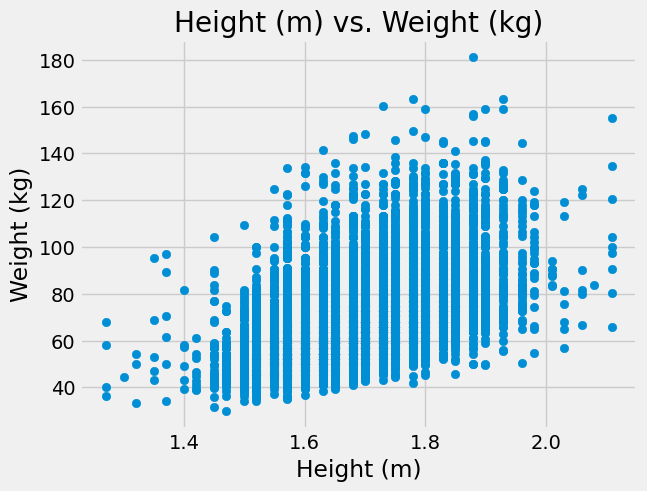

In [28]:
# This scatter plot is to visualize the relationship between height
# and weight.
plt.scatter(height_vs_weight['height'], height_vs_weight['weight'])
plt.xlabel("Height (m)")
plt.ylabel("Weight (kg)")
plt.title("Height (m) vs. Weight (kg)");

This scatter plot shows a positive relationship between height and weight, indicating that weight generally does increase as height increases. By finding the correlation coefficeint of approximately 0.51, we see that there is a moderate positive relationship between the two. However, in the graph, we can see that there are many students with the same heights, varying in weights. This suggests that height and weight alone do not fully determine proportional body composition.

We decided that next we should examine the body mass index and how it relates to a participant's activity level.

For Phase 3 Grading:
    
* Who made this graph?  Arianna
* Who asked the question?  Arianna
* Who did the write-up?  Arianna
* Found the correlation coefficient between height and weight: Arianna

### 3.2 -  Analyzing BMI Patterns Across Activity Level Groups in the YRBSS Dataset

Physical health may also depend on lifestyle behaviors such as activity levels. Because two participants with similar body weights can differ in fitness levels, we decided to investigate whether activity frequency is associated with differences in BMI patterns. We first started by analyzing how average activity per week, separated into low, moderate, and high activity level groups, relates to average BMI per activity level group.

In [29]:
#This code cell separates activity_days into 3 categories
# (Low, Moderate, High).
# Then takes the values of the height and weight columns
# to calcuate the average BMI per activity level group.
sql_statement = """
                    SELECT
                      CASE
                        WHEN active_days BETWEEN 0 AND 2 THEN 'Low'
                        WHEN active_days BETWEEN 3 AND 4 THEN 'Moderate'
                        ELSE 'High'
                      END AS activity_group,
                    ROUND(AVG(weight/(height*height)), 2) AS avg_bmi
                    FROM youth_survey
                    WHERE active_days IS NOT NULL
                      AND height IS NOT NULL
                      AND weight IS NOT NULL
                    GROUP BY activity_group
                    ORDER BY avg_bmi DESC;
                """
avg_bmi_activity = pd.read_sql_query(sql_statement, conn)
avg_bmi_activity

,activity_group,avg_bmi
0,Low,23.95
1,Moderate,23.91
2,High,23.30


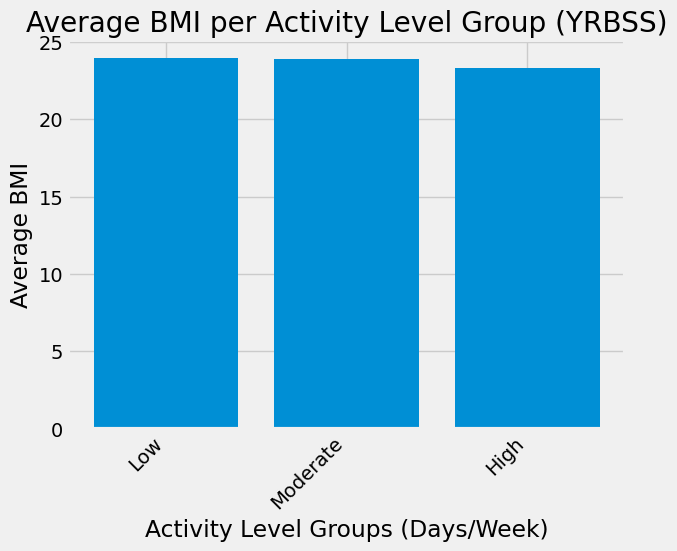

In [30]:
# This code cell creates a bar graph, showing the differences in BMI
# per activite level group.
plt.bar(avg_bmi_activity['activity_group'], avg_bmi_activity['avg_bmi'])
plt.xlabel("Activity Level Groups (Days/Week)")
plt.ylabel("Average BMI")
plt.title("Average BMI per Activity Level Group (YRBSS)")
plt.xticks(rotation = 45, ha='right');

From this visualization, we observe that the average BMI across each activity level group is relatively similar. Because we are only analyzing the averages, we must also analyze the distribution of BMI per activity level group to determine if there are any extreme values that do not heavily affect the averages.

In [31]:
# This code cell calculates all the BMIs of students who meet
# the conditions of the low activity level group.
sql_statement = """
                    SELECT ROUND(weight/POWER(height, 2), 1) AS BMI
                    FROM youth_survey
                    WHERE height IS NOT NULL
                      AND weight IS NOT NULL
                      AND active_days BETWEEN 0 AND 2;
                """

low_activity = pd.read_sql_query(sql_statement, conn)
low_activity

,BMI
0,21.8
1,20.8
2,27.2
3,51.7
4,24.7
...,...
4017,34.2
4018,21.8
4019,33.1
4020,18.8


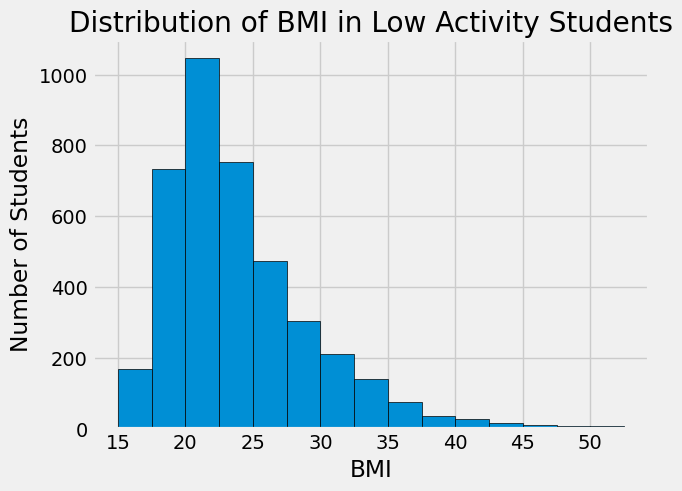

In [32]:
# This code cell creates a histogram to visualize the distribution on BMIs
# in the low activity level group.
plt.hist(low_activity['BMI'], bins = np.arange(15.0,55.0, 2.5), edgecolor = 'black')
plt.xlabel('BMI')
plt.ylabel('Number of Students')
plt.title('Distribution of BMI in Low Activity Students');

In [33]:
# This code cell calculates all the BMIs of students who meet
# the conditions of the moderate activity level group.
sql_statement = """
                    SELECT ROUND(weight/POWER(height, 2), 1) AS BMI
                    FROM youth_survey
                    WHERE height IS NOT NULL
                      AND weight IS NOT NULL
                      AND active_days BETWEEN 3 AND 4;
                """

mod_activity = pd.read_sql_query(sql_statement, conn)
mod_activity

,BMI
0,48.3
1,20.2
2,25.3
3,24.6
4,34.6
...,...
2551,21.3
2552,26.5
2553,25.8
2554,28.4


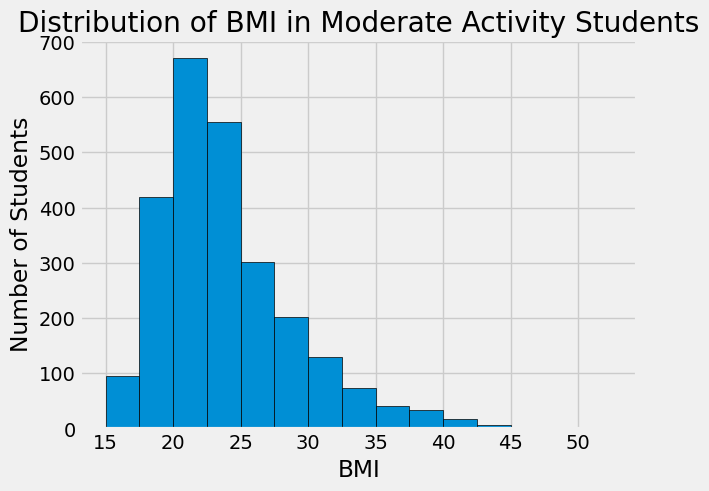

In [34]:
# This code cell creates a histogram to visualize the distribution on BMIs
# in the moderate activity level group.
plt.hist(mod_activity['BMI'], bins = np.arange(15.0,55.0, 2.5), edgecolor = 'black')
plt.xlabel('BMI')
plt.ylabel('Number of Students')
plt.title('Distribution of BMI in Moderate Activity Students');

In [35]:
# This code cell calculates all the BMIs of students who meet
# the conditions of the high activity level group.
sql_statement = """
                    SELECT ROUND(weight/POWER(height, 2), 1) AS BMI
                    FROM youth_survey
                    WHERE height IS NOT NULL
                      AND weight IS NOT NULL
                      AND active_days BETWEEN 5 AND 7;
                """

high_activity = pd.read_sql_query(sql_statement, conn)
high_activity

,BMI
0,28.2
1,20.7
2,26.5
3,21.7
4,22.2
...,...
5781,20.4
5782,18.8
5783,23.0
5784,30.1


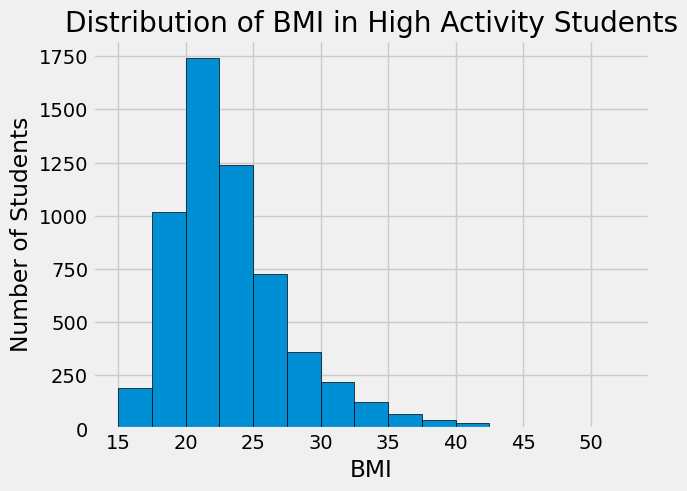

In [36]:
# This code cell creates a histogram to visualize the distribution on BMIs
# in the high activity level group.
plt.hist(high_activity['BMI'], bins = np.arange(15.0,55.0, 2.5), edgecolor = 'black')
plt.xlabel('BMI')
plt.ylabel('Number of Students')
plt.title('Distribution of BMI in High Activity Students');

Because of the similar averages in BMI per activity level group, examining the distribution of BMI in the different activity level groups helps identify any outliers.

Based off of the visualization of the distrbution of BMI in low activity level students, while majority of students fall within the range of roughly 20-25, we can see that this group contains more extreme outliers of participants with BMI values of above 50.

Based off of the other visualizations of moderate and high activity groups, majority of students in either group fall within the same range of roughly 20-25; however, there are still outliers that do have higher BMI values, but values that are lower than the low activey level group. The moderate activity level group does have slightly more students with higher BMI levels than the high activity level group.

Together, all the graphs do suggest that activity level does have a relationship with BMI; however, it does not fully explain if BMI increases as activity level decreases. Because majority of students in each activity level group maintain BMI values of 20-25, other factors such as diet or exercise intensity and duration that may be associated with BMI are not captured in this examination.

Because activity frequency may not fully capture other factors that influence BMI, we analyze a second dataset using weekly activity hours for comparison.

For Phase 3 Grading:
    
* Who made these graph?  Arianna
* Who asked the question?  Arianna
* Who did the write-up?  Arianna

### 3.3 - Analyzing BMI Patterns Across Activity Level Groups in the Kaggle Dataset

To further examine whether activity level related to BMI, we use a different measure of exercise frequency, in hours as opposed to days, from a second dataset.

In [37]:
# This code cell is used to calculate the average BMI
# per activity level group from the
# Kaggle Student PE Performance dataset.
sql_statement = """
                    SELECT ROUND(AVG(BMI), 2) AS avg_bmi,
                      CASE
                        WHEN hours_activity >= 0 AND
                         hours_activity < 4 THEN 'Low'
                        WHEN hours_activity >= 4 AND
                         hours_activity < 7 THEN 'Moderate'
                        WHEN hours_activity >= 7 THEN 'High'
                      END AS activity_level
                    FROM student_activity
                    WHERE hours_activity IS NOT NULL
                      AND BMI IS NOT NULL
                    GROUP BY activity_level
                    HAVING activity_level IS NOT NULL
                    ORDER BY avg_bmi DESC;

                """

kaggle_bmi_activity = pd.read_sql_query(sql_statement, conn)
kaggle_bmi_activity

,avg_bmi,activity_level
0,22.06,Low
1,22.03,Moderate
2,21.90,High


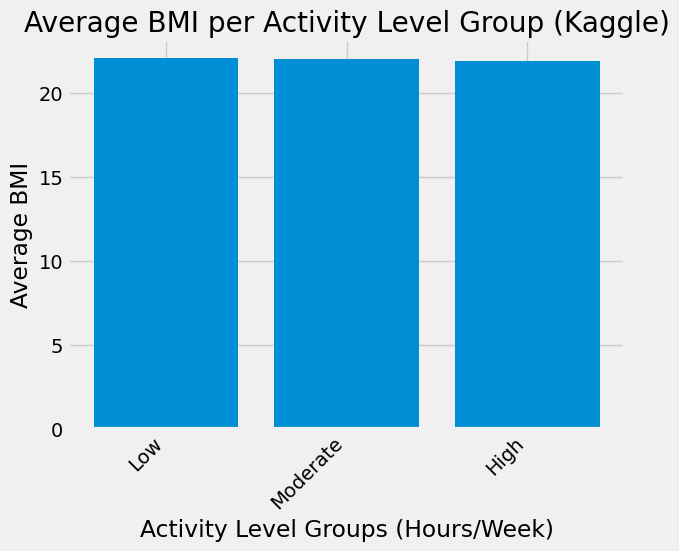

In [38]:
# This code cell creates a bar graph, visualizing the
# average BMI values of each activity level group.
plt.bar(kaggle_bmi_activity['activity_level'], kaggle_bmi_activity['avg_bmi'])
plt.xlabel("Activity Level Groups (Hours/Week)")
plt.ylabel("Average BMI")
plt.title("Average BMI per Activity Level Group (Kaggle)")
plt.xticks(rotation = 45, ha='right');

Similarly to the YRBSS average BMI graph, the average BMI values are rougly the same across activity level groups. Thus, we must also examine the distribution of BMI in each activite level group.

In [39]:
# This code cell creates a histogram to visualize the distribution on BMIs
# in the high activity level group of the Kaggle dataset.
sql_statement = """
                    SELECT ROUND(bmi, 2) AS bmi
                    FROM student_activity
                    WHERE hours_activity >= 0
                      AND hours_activity < 4
                      AND bmi IS NOT NULL;

                """

kaggle_low = pd.read_sql_query(sql_statement, conn)
kaggle_low

,bmi
0,19.39
1,24.04
2,25.42
3,17.63
4,18.42
...,...
101,23.01
102,23.96
103,24.96
104,22.29


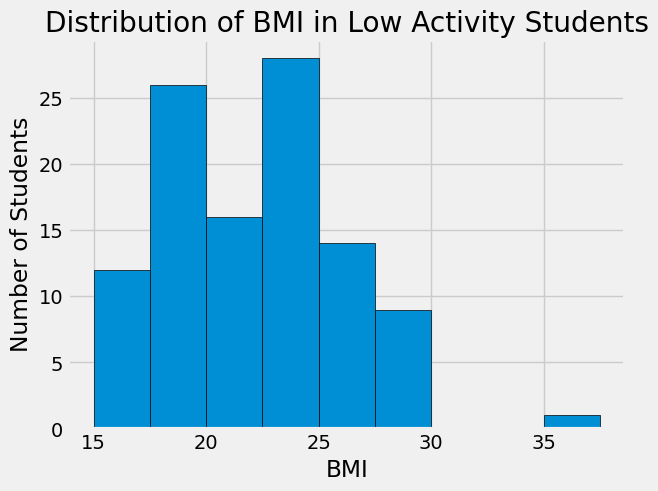

In [49]:
# This code cell creates a histogram to visualize the distribution on BMIs
# in the low activity level group.
plt.hist(kaggle_low['bmi'], bins = np.arange(15.0,40.0, 2.5), edgecolor = 'black')
plt.xlabel('BMI')
plt.ylabel('Number of Students')
plt.title('Distribution of BMI in Low Activity Students');

In [50]:
# This code cell creates a histogram to visualize the distribution on BMIs
# in the moderate activity level group of the Kaggle dataset.
sql_statement = """
                    SELECT ROUND(bmi, 2) AS bmi
                    FROM student_activity
                    WHERE hours_activity >= 4
                      AND hours_activity < 7
                      AND bmi IS NOT NULL;

                """

kaggle_moderate = pd.read_sql_query(sql_statement, conn)
kaggle_moderate

,bmi
0,29.24
1,21.13
2,18.61
3,18.86
4,20.52
...,...
204,15.08
205,22.17
206,23.77
207,25.81


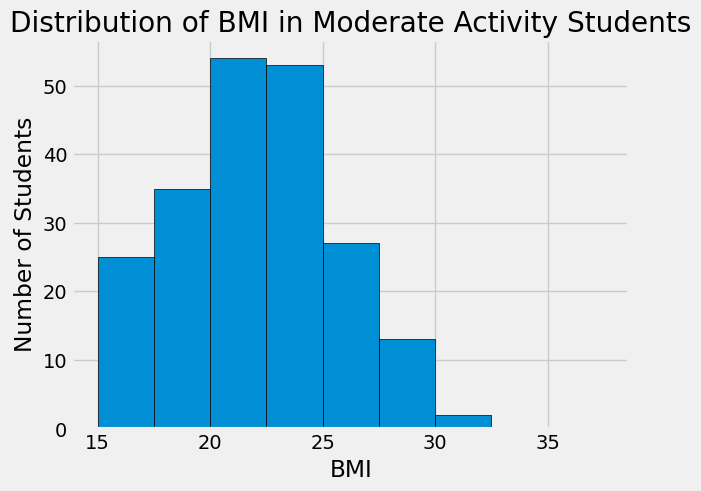

In [51]:
# This code cell creates a histogram to visualize the distribution on BMIs
# in the moderate activity level group.
plt.hist(kaggle_moderate['bmi'], bins = np.arange(15.0,40.0, 2.5), edgecolor = 'black')
plt.xlabel('BMI')
plt.ylabel('Number of Students')
plt.title('Distribution of BMI in Moderate Activity Students');

In [43]:
# This code cell creates a histogram to visualize the distribution on BMIs
# in the high activity level group of the Kaggle dataset.
sql_statement = """
                    SELECT ROUND(bmi, 2) AS bmi
                    FROM student_activity
                    WHERE hours_activity >= 7
                      AND bmi IS NOT NULL;

                """

kaggle_high = pd.read_sql_query(sql_statement, conn)
kaggle_high

,bmi
0,17.64
1,16.38
2,25.61
3,28.08
4,26.12
...,...
180,28.62
181,20.35
182,27.98
183,23.89


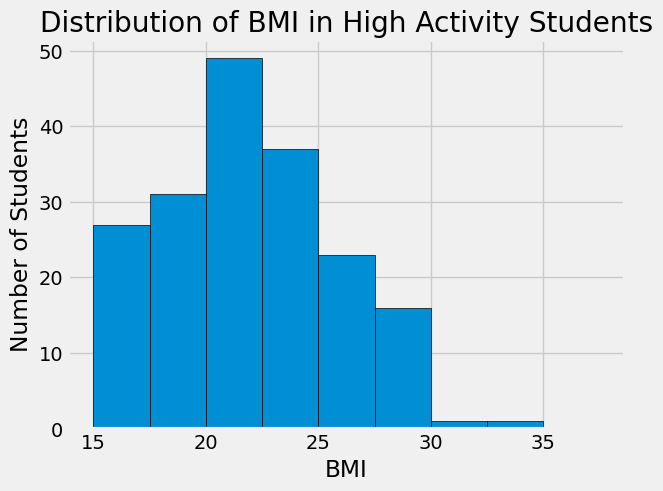

In [52]:
# This code cell creates a histogram to visualize the distribution on BMIs
# in the high activity level group.
plt.hist(kaggle_high['bmi'], bins = np.arange(15.0,40.0, 2.5), edgecolor = 'black')
plt.xlabel('BMI')
plt.ylabel('Number of Students')
plt.title('Distribution of BMI in High Activity Students');

Based of the visualizations of all three activity level groups in the Student PE Performance dataset, most participants range in BMI values roughly from 20-25. The low activity group does have an isolated high BMI outlier group roughly ranging from 35-37.5. The morderate activity group has fewer higher BMI outliers, than the high activity group, though the high activity group has the lowest BMI average of all the groups.

These visualizations also suggest that activity level alone does not influence the BMI of an individual and that other factors and behaviors may contribute.

Despite activity level not fully explaining BMI, because both datasets suggested similar patterns, we decided to join our findings to directly compare them.

For Phase 3 Grading:
    
* Who made these graphs?  Arianna
* Who asked the question?  Arianna
* Who did the write-up?  Arianna

### 3.4 - Consistent BMI Patterns Appear Across Both Datasets

To test whether the relationship between activity level and BMI is consistent between both datasets, we joined both datasets across activity levels to compare average BMI trends.

In [45]:
# This code cell is to create a new table containing only
# the average BMI values across activity level groups
# in order to make joining the YRBSS dataset with
# the Student PE Performance dataset less complicated.
cursor.execute("""
                    CREATE TABLE yrbss_bmi AS
                    SELECT
                      CASE
                        WHEN active_days BETWEEN 0 AND 2 THEN 'Low'
                        WHEN active_days BETWEEN 3 AND 4 THEN 'Moderate'
                        ELSE 'High'
                      END AS activity_group,
                    ROUND(AVG(weight/(height*height)), 2) AS avg_bmi
                    FROM youth_survey
                    WHERE active_days IS NOT NULL
                      AND height IS NOT NULL
                      AND weight IS NOT NULL
                    GROUP BY activity_group
                """)
conn.commit();

In [46]:
# This code cell is to create a new table containing only
# the average BMI values across activity level groups
# in order to make joining the Student PE Performance dataset with
# the YRBSS dataset less complicated.
cursor.execute("""
                    CREATE TABLE kaggle_bmi AS
                    SELECT ROUND(AVG(BMI), 2) AS avg_bmi,
                      CASE
                        WHEN hours_activity >= 0 AND
                         hours_activity < 4 THEN 'Low'
                        WHEN hours_activity >= 4 AND
                         hours_activity < 7 THEN 'Moderate'
                        WHEN hours_activity >= 7 THEN 'High'
                      END AS activity_level
                    FROM student_activity
                    WHERE hours_activity IS NOT NULL
                      AND BMI IS NOT NULL
                    GROUP BY activity_level
                    HAVING activity_level IS NOT NULL

                """)
conn.commit();

In [47]:
# This code cell is to join both datasets on activity level groups
# to compare average BMI.
sql_statement = """
                    SELECT y.activity_group,
                           y.avg_bmi AS yrbss_bmi,
                           k.avg_bmi AS kaggle_bmi
                    FROM yrbss_bmi y
                    JOIN kaggle_bmi k
                      ON y.activity_group = k.activity_level
                    ORDER BY k.avg_bmi DESC, y.avg_bmi DESC;

                """

joined = pd.read_sql_query(sql_statement, conn)
joined

,activity_group,yrbss_bmi,kaggle_bmi
0,Low,23.95,22.06
1,Moderate,23.91,22.03
2,High,23.30,21.90


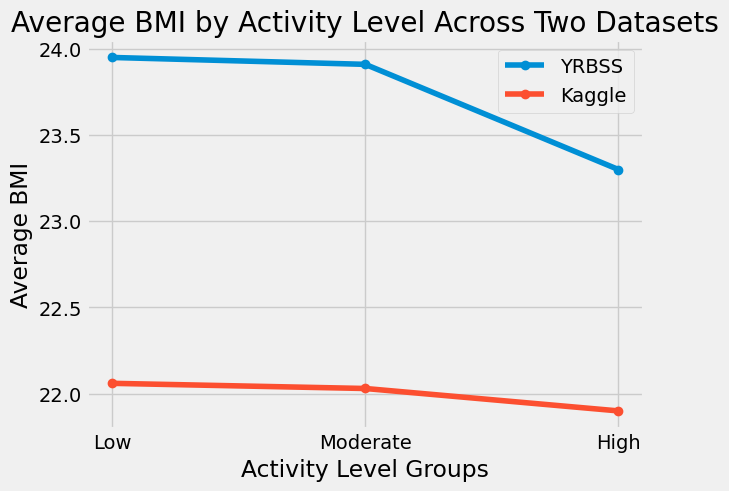

In [48]:
# This code cell is to visualize the trends in average BMI across
# average activity level groups across both datasets.
plt.plot(joined['activity_group'], joined['yrbss_bmi'], marker = 'o', label = 'YRBSS')
plt.plot(joined['activity_group'], joined['kaggle_bmi'], marker = 'o', label = "Kaggle")
plt.xlabel("Activity Level Groups")
plt.ylabel("Average BMI")
plt.title("Average BMI by Activity Level Across Two Datasets")
plt.legend();

In the visualization, we observe both datasets show a similar trend with BMI decreasing as activity level decreases, suggesting that these two graphs are consistent in showing that activity level may not be the only factor associated with the BMI of an individual. While both trends have a downward trend, the trend in the YRBSS data is noticeably larger between the moderate and high activity groups, whereas the trend in the Kaggle data is smaller. While the relationships slightly differ between both datasets, both datasets support the finding that higher activity levels may be associated with lower BMI values, but may not be the only factor associated with lower BMI values.

 For Phase 3 Grading:
    
* Who made this graph?  Arianna
* Who asked the question?  Arianna
* Who did the write-up?  Arianna

----

## 4. Conclusion

Overall, this analysis showed that height alone does not fully explain differences in body composition among students. While height and weight demonstrated a moderate positive relationship, students of similar height still showed varying weight and BMI. This suggested that there are other factors beyond height that may contribute to the variation in body composition.

To better examine these differences, BMI was used to combine the measures of height and weight, and activity level groups were compared across both datasets. The results showed that students in the higher activity level group generally had slightly lower BMI values. Although the differences in average BMI between activity level groups were relatively small, the distributions revealed outliers that the averages could not capture. In particular, the lower activity level group show more high BMI values, while the higher activity level groups shows more lower BMI values.

Comparing the YRBSS dataset to the Kaggle dataset also shows similar results. While activity level in the YRBSS table showed a stronger relationship in lower average BMI in the high activity group, both demonstrated slightly lower BMI values in higher activity level groups. This consistency suggests that physical activity may play a role in influencing BMI patterns among students.

However, BMI also has limitations as a measurement because it does not distinguish between fat mass and lean body mass. Future work could expand this analysis by incorporating additional factors such as diet, activity intensity and duration, body composition measures like body fat percentage, and other lifestyle factors.

If more time and additional data were available, future research can be done to examine body composition measurs beyond BMI, such as body fat persentation or lean body mass. We could also better examine activity levels, utilizing intensity and duration, to better understand how it influences body composition.